# Supervised Learning for Regression Problems

by Nadzeya Laurentsyeva @ nadzeya.laurentsyeva@econ.lmu.de

November 16, 2020


# Introduction 

_There are two cultures in the use of statistical modeling to reach conclusions
from data. One assumes that the data are generated by a given stochastic data
model. The other uses algorithmic models (aka *Machine learning*) and treats the data mechanism as
unknown._ Breiman (2001).

**Machine learning - the study of data-modelling algorithms that improve when new data arrives.**  

ML types
* Supervised learning: mapping from $x_i$ to $y_i$
    * Regression ($y_i$ is continuous) 
    * Classification ($y_i$ is categorical)
* Unsupervised learning: cluster observations, learn some structure within $x_i$

## Motivation 

Why in Economics: ML can diversify and enhance out set of tools

Applications:
* Working with new datasets, e.g. unstructured data 
* Prediction might be of interest (e.g. time-series analysis, IV)
* Model specification
* Heterogeneity analysis
* Experimental design  

Differences between ML and standard econometric methods: 
* Less focus on the underlying model or causal relationships (agnostic)
* Less focus on the statistical inference
* Less focus on theoretical proofs behind algorithms
* More focus on prediction
* More focus on working properties, computation and optimization


## This lecture: Focus on supervised learning for regression problems¶
    
Today's goals:   
* Understand key goals and features of the ML approach to regression problems
* Overview of ML methods for regression analysis
* Model regularisation exercise (in Python)
* ML tools and causal inference
    * Control selection (in Stata)
    * Instrument selection

## Tools and data for the lecture and the problem set

**Tools** 
* Regularised regression models: lasso, ridge, elastic nets
* Python (scikit-learn) and Stata packages (pdslasso, ivlasso)
<br>

**Datasets** 
* Model regularisation 
    * Trump's tweet data 
* Control selection 
    * Donohue and Levitt's data on abortion and crime used by Belloni et al. (2014) [Inference on Treatment Effects after Selection among High-Dimensional Controls](https://academic-oup-com.emedien.ub.uni-muenchen.de/restud/article/81/2/608/1523757)
* Instrument selection 
    * Data from Angrist and Krueger (1999) [Does compulsory school attendance affect schooling and earnings?](https://economics.mit.edu/faculty/angrist/data1/data/angkru1991)

All the datasets can be downloaded on moodle. 

# 1. Set-up and terminololgy 


**Problem** 

Estimate the conditional mean of a scalar outcome given a set of covariates (aka features). Let
$Y_i$ denote the outcome for unit $i$, and let $X_i$ denote the $K$-component vector of covariates. The conditional expectation: $ g(x) = E(Y_i | X_i = x) $. Our task is to estimate $g(\cdot)$. 

**Key terms**

* Training sample $==$ the sample used to estimate the parameters
* Test sample $==$ the sample used to validate the model
* Target $==$ outcome, dependent variable
* Features $==$ regressors, covariates, or predictors
* Weights $==$ sometimes, regression parameters, coefficients
* Parameter of interest $==$ main independent variable
* Nuisance features/parameters $==$ controls
* Deviance $==$ measure of the distance between data and fit

# 2. Goals and features of the ML approach to regression problems

## Goals
* Make predictions about some variables given others
* Focus on developing efficient algorithms to solve these problems, mostly no presumption that the conditional distribution of the outcomes given the covariates follows a particular model

_Compare with the econometric analysis where the target is to recover a causal or structural parameter of a certain model_. 

## Features/concerns
* Validation and cross-validation with out-of-sample tests 
    * _When you apply your models for prediction and decision-making, you don't actually care about the in-sample fit. All that matters is the out-of-sample fit or how easy does your model fit new data._ (Matt Taddy)
    
* Over-fitting and regularisation 
* Sparsity 
    * Assumption that only a limited number of features are relevant for the outcome, however rather than taking these features from the outside (e.g. economic theory), use data to select them.  
* Computing and scalability
* Ensemble methods and model averaging

## Supervised learning methods
* **Parametric - think of a familiar regression analysis (today)**
* Non-parametric 
    * Random forests and causal trees (December 11 and 18)
* Semi-parametric 
    * Deep-learning and neural nets (January 15)

## Evaluating an algorithm

**K-fold out-of-sample (cross-)validation** 

* Common way to test the validity of a model and to compare the performance of different models
* Given a dataset of $N$ observations: 
    * Split the data into $K$ evenly sized random subsets (folds)
    * For k = 1...K: 
        * Fit the coefficients $\hat{\beta}$ using all but the $k^{th}$ fold of data 
        * Record $R^2$ on the left-out $k^{th}$ fold 
        * Note: for anything that you do to the data (e.g. standardisation, interpolation, feature selection), do it without the left-out fold to get an accurate assessment of the model's performance. 
* This will yield a sample of $K$ out-of-sample $R^2$ values. This sample is an estimate of the distribution of the model's predictive performance on new data. 

* Question: can you theoretically get negative $R^2$ for out-of-sample tests? 
    * Yes: Consider a linear regression, with $R^2 = 1 - \dfrac{RSS}{TSS}$, where $TSS$ - total sum of squares, corresponds to the deviance of a null model $\sum_i(y_i - \bar{y})^2$ and $RSS$ - residual sum of squares after fitting the model. We can see that the negative result will occur if the model performs worse than the null model.

# 3. Overview of ML tools for regression problems

## Why is 'just' regression not enough? 
Consider a familiar linear regression, which is a simple supervised learning model. Here we choose a vector of coefficients $\beta$ to minimise: 

$ RSS(\beta) = \sum_i (y_i-x_i^T\beta)^2 $

and the solution $\hat{\beta^{OLS}} = (X^TX)^{-1})(X^Ty) $

With $K$ > $N$, the OLS solution is not well defined. With $K$ being large (as in many data science problems), the least squares estimator has poor prediction properties.
* Overfitting: the production of an analysis that corresponds too closely or exactly to a particular set of data, and may therefore fail to fit out-of-sample data 
<br>

* Multiplicity: assume we have 100 covariates and 5 of them have real relationship with the outcome; the rest are noise. We manage to find all 5 true ones and test the remaining 95 with an $ \alpha = 0.05 $ significance cutoff. We can expect that $5\% (\sim 5)$ out of 95 remaining coefficients will turn out significant: Our false discovery rate (FDR) will be then $ \dfrac{N\ false\  positives}{N\  significant\  tests} = 5/10 = 50\% $. 
<br>

* Why is it bad: we add noise to the model and reduce the quality of the predictors 

Solution: regularise the model = reduce the model's complexity. 


## Controlling expected false discovery rate
Benjamini-Hochberg (BH) FDR Control Algorithm https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectFdr.html
* Allows to fix an acceptable FDR and sets a cut-off for p-values (often much lower than conventional 0.1 or 0.05) to ensure such FDR. 
* Identify covariates with acceptable p-values and re-run the regression  
* Relies on a strong (and often unrealistic) assumption of independence between significance tests, therefore often gives too conservative results. 


## Regularised regressions

One common form of regularization is to augment our loss (deviance) function with a term that directly penalises the complexity (puts a cost on the size of coefficients). For example, in the case of a linear regression, we will then minimise 

$ \sum_i (y_i-x_i^T\beta)^2  + \lambda h(\beta) $ 

Two new terms are: 
* $\lambda > 0$ - defines the strength of the penalty
    * tuning parameter, selected during the estimation  in some data-dependent matter
* $h(\cdot)$ - controls the shape of the penalty, non-decreasing in $\beta$
    * Lasso: $h(\beta) = \sum_k |\beta_k| $
    * Ridge: $h(\beta) = \sum_k (\beta_k)^2 $
    * Elastic net: $h(\beta) = \sum_k |\beta_k| + \gamma \sum_k(\beta_k)^2 $
    * Nonconvex penalty: $h(\beta) = \sum_k (log(1+|\beta|)) $ 
    * Other possible variations 
    
**Main trade-off: variance vs. bias** 
//will add a theoretical explanation here// 

**How to select $h(\cdot)$?** 
* Start by thinking about your covariates and which signals you want to capture. E.g. if you believe that each of  your covariates has a small effect on the outcome, ridge might be appropriate. On the contrary, if you think that there are a few of very important coefficients, a log penalty will generate many zeros but will allow large signals to be estimated with a smaller bias. 
* For many applications, Lasso is a good starting point. 
    * Places a constant penalty on deviations from zero
    * Will yield automatic variable screening: some of the coefficients will be exactly equal to zero. It happens when the penalty dominates the deviance term (of course, not only Lasso has such property). 
    
**How to select $\lambda$?** 
* K-fold cross-validation - CV
    * Obtain a path of candidate models (corresponding to different levels of $ \lambda$)
    * For k = 1...K folds:
        * Fit the candidate models using all but the $k^{th}$ fold of data 
        * Calculate the fit of each model for the left-out $k^{th}$ fold
    * Choose the best $\lambda$, i.e. that minimises the average out-of-sample error or the largest $\lambda$
such that error is within one standard deviation of minimum.
    * Use the corresponding full-sample coefficient estimates for modeling and predictions
* Information criteria - IC 
    * Another way is to select lambda based on information criteria. These are analytic approximations to the types of out-of-sample errors that cross-validation estimates using a computational experiment. We would then use the model with minimum IC. 
    * There are many variations of ICs (AIC, AICc, BIC, etc.) 
        Ex: $AIC = deviance + 2df$, where $df$ - model's degrees of freedom. Conveniently, in lasso degrees of freedom simply equal to the number of nonzero coefficients at a given $ \lambda$. 
    * What is better IC or CV approach? Depends on your data and computational resources
        * CV can become costly if we work with huge datasets and complex models
        * AIC performs well for high N/df, but overfits in high-dimensional data. AICc corrects for that and is faster and more stable compared to CV. 
        * BIC tends to underfit in large samples

In [ ]:
## Would be good to add here an illustration of how regularisation works. Theoretical exercise? 

       
**Some tips for the problem set**
* Factor reference levels matter under penalisation => get rid of the reference level (create separate dummies for each factor level)
* Size of the covariates now matters, as all $\beta_k$ are penalised by the same $\lambda$ => several solutions possible: i) standardise covariates; ii) standardise $\beta$'s in the cost function, e.g. by multiplying the coefficients by standard deviation of corresponding covariates. Note: you might still want to avoid standardisation if you have all indicator variables as your covariates. 

## 4. ML and causal inference 

In some cases, we can just take ML methods and apply to our (economic research) problems. In particular, when we need to classify/reduce dimensionality of data or when we are mostly concerned about the prediction power of the model. 

In some cases, ML methods are not directly applicable for research questions in econometrics and allied fields, especially when it comes to causal inference.

Why: remember penalised regression and its trade-off between variance and bias. 

## Model selection 

One example, where ML methods can be helpful, is in model selection.

!_We still need to be sure in the causal variable (identification), but can use ML tools to select proper controls and specification_! 
* Selection of controls, to address omitted variable bias.
* Selection of instruments, when there are potentially many of them and we are not sure which are relevant

**Why ML tools can help?** 
* We do not know the true model behind data 
* Risk of over-fitting 
* Omitted variable bias, we do not include relevant confounders
* “Researcher degrees of freedom” and“p-hacking”. Researchers may consciously or unconsciously choose controls to generate the results they want.

**Model selection with ML**

Why won't a naive approach (just run a Lasso regression of $y$ on the causal variable (not subject to selection) and possible controls) work? 

-We might miss controls that have a strong predictive power for the causal variable, but only a small effect on the outcome. If we only consider the regression of the causal variable against the controls, we might miss controls that have a strong predictive power for the outcome, but only a moderately sized effect on the causal variable.

*Post-Double-Selection Lasso

1. Drop d. Use Lasso to see which controls are important for y --> A. 
2. Drop y. Use Lasso to see which controls are important for d --> B.
3. Estimate with OLS y = f(d, A+B). 

Note: parameter for d is causal, but do not overinterpret coefficients for A and B controls!

*Alternative: Double-Orthogonalization 

1. Run a regression of y on controls with Lasso; use Lasso or Post-Lasso coefficients to obtain residuls
2. Run a regression of d on controls with Lasso; again obtain residuals
3. Run OLS of y resid. on d resid. 
4. No temptation to overinterpret controls! 

*Why does it work? 
* Immunisation property - we use prediction to identify controls=nuisance parameters, moderate model selection mistakes of the LASSO do not affect the asymptotic distribution of the causal estimator

* Irrepresentable condition - we do not aim at giving causal interpretation to controls

# Problem Set: Model Regularisation 

Our task is to predict the success of Donald Trump's tweets as measured by the favorite count (outcome). 
Our dataset includes tweet-level data with some information about each tweet: timestamp, length. In addition, I used LDA to identify 100 latent 'topics' (components) from tweets' text. Thus, we also have some signals about the contents of each tweet. You can check the code to generate the dataset on moodle. You will learn more about LDA approach in the next lecture. 

**Part 1**
1. Fit an ordinary linear regression on the whole sample. Which covariates would you add? What is in-sample $R^2$? 
2. Apply the Benjamini - Hochberg algorithm to obtain a smaller model. Set FDR at $5\%$. How many regressors are left?  What is the cutoff for p-values? What is in-sample $R^2$? 
3. Now let's use K-fold out-of-sample validation to compare the predictive power of the full and of the reduced model. To better visualise the difference, let's plot the resulting out-of-sample $R^2$ for the models.  What is your conclusion? 

**Part 2**
1. Now let's estimate the model using lasso
2. Use the full sample to find lasso regularisation path and have a better idea for our candidate models 
3. Use K-fold out-of-sample validation to select the 'best' $\lambda$. Plot average out-of-sample $R^2$ as a function of $\lambda$. 
4. Compare the results with AIC/AICc/BIC criteria. 

**On your own**
Repeat the steps in Part 2 using another penalty (e.g. elastic net, ridge) instead of lasso. 

#### Preparing the dataset

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

path = "C:/Users/nadzeya/Documents/teaching/Data_science_2020_ss/lectures" 
os.chdir(path)
data = pd.read_csv("tweets_lda.csv")
data.shape

(45539, 110)

In [2]:
data.head()

,id_str,timestamp,retweet_count,favorite_count,year,month,dayofyear,dayofweek,hour,length,...,lda_topic_90,lda_topic_91,lda_topic_92,lda_topic_93,lda_topic_94,lda_topic_95,lda_topic_96,lda_topic_97,lda_topic_98,lda_topic_99
0,1.262024e+18,2020-05-17 09:15:53,9741.0,43484,2020,5,138,6,9,104,...,0.706362,0.002966,0.002966,0.002966,0.002966,0.002966,0.002966,0.002966,0.002966,0.002966
1,1.262020e+18,2020-05-17 09:01:31,11630.0,61214,2020,5,138,6,9,91,...,0.002926,0.002926,0.002926,0.002926,0.002926,0.002926,0.002926,0.002926,0.002926,0.002926
2,1.262006e+18,2020-05-17 08:03:32,16368.0,0,2020,5,138,6,8,99,...,0.003222,0.003222,0.003222,0.003222,0.003222,0.003222,0.003222,0.003222,0.003222,0.003222
3,1.261999e+18,2020-05-17 07:37:30,7108.0,0,2020,5,138,6,7,140,...,0.002707,0.002707,0.002707,0.002707,0.002707,0.151772,0.002707,0.002707,0.002707,0.002707
4,1.261998e+18,2020-05-17 07:34:18,4685.0,30176,2020,5,138,6,7,75,...,0.002754,0.092606,0.002754,0.002754,0.002754,0.002754,0.002754,0.002754,0.002754,0.002754


In [3]:
# add squared length and take logs of favorite_count and length
data.insert(10, 'length2', data['length']**2)
for x in ['favorite_count', 'length', 'length2']:
    data[x] = np.log(data[x]+1)

In [4]:
data.describe()

,id_str,retweet_count,favorite_count,year,month,dayofyear,dayofweek,hour,length,length2,...,lda_topic_90,lda_topic_91,lda_topic_92,lda_topic_93,lda_topic_94,lda_topic_95,lda_topic_96,lda_topic_97,lda_topic_98,lda_topic_99
count,4.553900e+04,45539.000000,45539.000000,45539.000000,45539.000000,45539.000000,45539.000000,45539.000000,45539.000000,45539.000000,...,45539.000000,45539.000000,45539.000000,45539.000000,45539.000000,45539.000000,45539.000000,45539.000000,45539.000000,45539.000000
mean,7.284901e+17,7902.219175,5.864442,2015.846988,6.462549,181.135115,2.749248,12.946310,4.758605,9.496434,...,0.008139,0.008128,0.012636,0.007836,0.008656,0.008580,0.013430,0.010131,0.008806,0.010735
std,3.512493e+17,12043.921277,4.185435,2.674487,3.506796,106.811303,1.916522,5.679015,0.581156,1.177120,...,0.042186,0.044427,0.060078,0.040547,0.045059,0.043605,0.064314,0.052123,0.045456,0.054446
min,1.698309e+09,0.000000,0.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,1.098612,1.609438,...,0.000431,0.000431,0.000714,0.000431,0.000431,0.000714,0.000737,0.000431,0.000714,0.000431
25%,4.174620e+17,37.000000,2.708050,2013.000000,3.000000,87.000000,1.000000,8.000000,4.532599,9.043695,...,0.002291,0.002292,0.002298,0.002293,0.002293,0.002293,0.002298,0.002293,0.002293,0.002297
50%,6.677116e+17,1492.000000,4.882802,2015.000000,7.000000,182.000000,3.000000,13.000000,4.875197,9.735128,...,0.002541,0.002540,0.002552,0.002543,0.002543,0.002544,0.002552,0.002544,0.002544,0.002548
75%,1.103430e+18,13215.000000,10.628485,2019.000000,10.000000,278.500000,4.000000,17.000000,4.941642,9.869000,...,0.002958,0.002955,0.002991,0.002963,0.002965,0.002966,0.002995,0.002967,0.002965,0.002974
max,1.262024e+18,369530.000000,13.687277,2020.000000,12.000000,366.000000,6.000000,23.000000,9.923633,19.847169,...,0.791293,0.793503,0.815971,0.779946,0.805854,0.778821,0.791076,0.818324,0.815091,0.811711


In [5]:
# create dummies for categorical variables: year, month, dayofyear, dayofweek, hour
# i.year i.dayofweek ...
dummies = [pd.get_dummies(data[i], prefix=i, drop_first = False) for i in ['year', 'dayofyear', 'dayofweek', 'hour']]

In [6]:
# We will not use it in the lecture, but you can also add (polynomial) interaction terms
# Sklearn has a useful feature for that
# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html#sklearn.preprocessing.PolynomialFeatures

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
# bias - vector of one's (constant)

# as an example, let's add interactions of hour of the day and length of a tweet 
# attention: the original variables are also returned, so we need to keep that in mind when we construct our covariates
inter = pd.DataFrame(poly.fit_transform(dummies[3].join(data['length'])))


In [7]:
# Inputs for the regression
y = data['favorite_count']
X = data.iloc[:, 9:].join(dummies)
X.head()
#X_short = data[['length', 'length2']].join(dummies) #covariates without LDA components
#X_long = data.iloc[:,12:].join(data['constant']).join(dummies[0:3]).join(inter) # with interactions

,length,length2,lda_topic_0,lda_topic_1,lda_topic_2,lda_topic_3,lda_topic_4,lda_topic_5,lda_topic_6,lda_topic_7,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,4.653960,9.288874,0.002966,0.002966,0.002966,0.002966,0.002966,0.002966,0.002966,0.002966,...,0,0,0,0,0,0,0,0,0,0
1,4.521789,9.021840,0.002926,0.002926,0.002926,0.002926,0.002926,0.002926,0.002926,0.002926,...,0,0,0,0,0,0,0,0,0,0
2,4.605170,9.190342,0.003222,0.003222,0.003222,0.003222,0.003222,0.003222,0.356749,0.003222,...,0,0,0,0,0,0,0,0,0,0
3,4.948760,9.883336,0.002707,0.002707,0.002707,0.002707,0.002707,0.002707,0.002707,0.002707,...,0,0,0,0,0,0,0,0,0,0
4,4.330733,8.635154,0.002754,0.002754,0.002754,0.002754,0.002754,0.002754,0.002754,0.002754,...,0,0,0,0,0,0,0,0,0,0


#### OLS

In [8]:
# ordinary linear regression
# statsmodel is more suited for traditional econometric analyses, but it is a good starting point 
import statsmodels.api as sm
est = sm.OLS(y, X).fit()
X = sm.add_constant(X)
est.summary()

C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\compat\pandas.py:49: FutureWarning: The Panel class is removed from pandas. Accessing it from the top-level namespace will also be removed in the next version
  data_klasses = (pandas.Series, pandas.DataFrame, pandas.Panel)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         favorite_count   R-squared:                       0.412
Model:                            OLS   Adj. R-squared:                  0.405
Method:                 Least Squares   F-statistic:                     62.32
Date:                Tue, 10 Nov 2020   Prob (F-statistic):               0.00
Time:                        01:28:42   Log-Likelihood:            -1.1772e+05
No. Observations:               45539   AIC:                         2.365e+05
Df Residuals:                   45032   BIC:                         2.409e+05
Df Model:                         506                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
length          110.3954      4.082     27.045      0.000     102.395     118.396
length2         -54.1696      2.016    -26.865      0.000     -58.122     -50.218
lda_topic_0      -0.5870      0.351     -1.672      0.095      -1.275       0.101
lda_topic_1       0.9345      0.307      3.049      0.002       0.334       1.535
lda_topic_2       0.4701      0.304      1.549      0.121      -0.125       1.065
lda_topic_3      -0.7121      0.390     -1.824      0.068      -1.477       0.053
lda_topic_4      -0.4398      0.279     -1.576      0.115      -0.987       0.107
lda_topic_5       0.1431      0.233      0.614      0.539      -0.314       0.600
lda_topic_6      -0.3815      0.212     -1.800      0.072      -0.797       0.034
lda_topic_7      -0.4753      0.322     -1.478      0.140      -1.106       0.155
lda_topic_8      -1.3125      0.314     -4.174      0.000      -1.929      -0.696
lda_topic_9      -1.3563      0.255     -5.316      0.000      -1.856      -0.856
lda_topic_10     -0.7364      0.316     -2.332      0.020      -1.355      -0.117
lda_topic_11      1.3481      0.290      4.651      0.000       0.780       1.916
lda_topic_12     -0.0560      0.344     -0.163      0.871      -0.730       0.619
lda_topic_13      0.5307      0.260      2.039      0.041       0.020       1.041
lda_topic_14     -0.9461      0.383     -2.468      0.014      -1.698      -0.195
lda_topic_15     -1.3112      0.364     -3.604      0.000      -2.024      -0.598
lda_topic_16      0.8898      0.352      2.528      0.011       0.200       1.580
lda_topic_17     -1.0923      0.262     -4.164      0.000      -1.606      -0.578
lda_topic_18     -2.7424      0.354     -7.742      0.000      -3.437      -2.048
lda_topic_19      0.8506      0.252      3.380      0.001       0.357       1.344
lda_topic_20      0.9163      0.329      2.789      0.005       0.272       1.560
lda_topic_21     -0.8557      0.327     -2.618      0.009      -1.496      -0.215
lda_topic_22     -3.1061      0.260    -11.955      0.000      -3.615      -2.597
lda_topic_23      0.5663      0.260      2.176      0.030       0.056       1.076
lda_topic_24      0.0970      0.227      0.428      0.669      -0.347       0.541
lda_topic_25      1.3342      0.243      5.491      0.000       0.858       1.811
lda_topic_26     -0.6316      0.322     -1.964      0.050      -1.262      -0.001
lda_topic_27     -0.6740      0.316     -2.131      0.033      -1.294      -0.054
lda_topic_28     -0.2261      0.386     -0.585      0.558      -0.983       0.531
lda_topic_29      1.1047      0.330      3.348      0.001       0.458       1.751
lda_topic_30     -2.1335      0.340     -6.280      0.000      -2.799      -1.468
lda_topic_31     -0.0253      0.320     -0.079      0.937      -0.652       0.601
lda_topic_32      1.7447      0.265      6.580   

In [9]:
# we can do the same with the scikit package, 
# it is better suited for ML applications (prediction), however does not return usual summary statistics  
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#examples-using-sklearn-linear-model-linearregression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

y = data['favorite_count']
X = data.iloc[:, 9:].join(dummies)

regr = LinearRegression(fit_intercept = True, normalize=False, copy_X=False, n_jobs=-1) # if we use defaults, the option can be skipped
regr.fit(X, y)

# Make in-sample predictions 
y_pred = regr.predict(X)
# The mean squared error
print('Mean squared error in-sample: %.3f'
      % mean_squared_error(y, y_pred))
# In-sample R-sq.
print('In-sample Rsq in-sample: %.3f'
      % r2_score(y, y_pred))
#print('In-sample Rsq:', regr.score(X, y))
#print('Coefficients: \n', regr.coef_)

Mean squared error in-sample: 10.306
In-sample Rsq in-sample: 0.412


In [10]:
regr.score(X,y) # to generate R2 in a fast way

0.41186086719405285

#### Pipeline, standardisation, simple sample-splitting
We are still doing simple linear regressions, but will now make our workflow more suitable to evaluate the prediction power of the model. 
* We will divide the underlying dataset on training and test data and evaluate the out-of-sample fit
* For Lasso estimations, it is recommended to standardise the covariates and to pass them as Fortran contiguous array. We will already add these operation to our workflow
* We will use _pipeline_ option to make sure we modify only the train data before estimating the coefficients

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

y = data['favorite_count']
X = data.iloc[:, 9:].join(dummies)
X = pd.DataFrame(np.ascontiguousarray(X.values), columns=X.columns) #Fotran array to save memory

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1)

pipe = Pipeline([('scaler', StandardScaler()), 
                 ('regr', LinearRegression(fit_intercept = False, normalize=False, copy_X=False, n_jobs=-1))])
# The pipeline can be used as any other estimator
# and avoids leaking the test set into the train set

pipe.fit(X_train, y_train)
print('In-sample Rsq: % .4f'
     % pipe.score(X_train, y_train))
print('Out-of-sample Rsq: % .4f'
     % pipe.score(X_test, y_test))

# you can experiment and increase the test size to 0.9 for example, to see how predictive power changes when the ratio 
# of Nobs to parameters decreases.

In-sample Rsq:  0.3702
Out-of-sample Rsq:  0.3359


#### Benjamini - Hochberg Algorithm

In [11]:
# Now let's apply Benjamini - Hochberg as a first attempt to regularise the model 
from sklearn.feature_selection import SelectFdr, f_regression
y = data['favorite_count']
X = data.iloc[:, 9:].join(dummies)
X = pd.DataFrame(np.ascontiguousarray(X.values), columns=X.columns)
X = StandardScaler().fit_transform(X)

fdr = SelectFdr(f_regression, alpha=0.05) # here alpha is our acceptable rate of finding false positives 
X_new =fdr.fit_transform(X, y)

In [13]:
print(X.shape, X_new.shape)

(45539, 507) (45539, 273)


In [12]:
# Cutoff pvalue for selected features 
sorted = pd.Series(fdr.pvalues_.T).sort_values(axis=0, ascending=True).reset_index(drop = True)
print("Cutoff p-value: % .4f" % sorted.loc[X_new.shape[1]])

Cutoff p-value:  0.0240


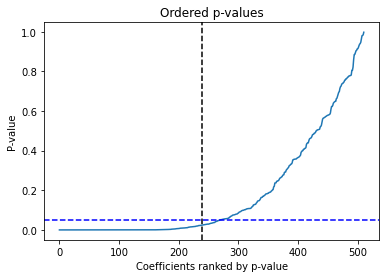

In [13]:
# Plot ordered pvalues
ax = sorted.plot.line(title = "Ordered p-values")
ax.set(xlabel="Coefficients ranked by p-value", ylabel="P-value")
ax.axvline(X_new.shape[1], color='k', linestyle='--')
ax.axhline(0.05, color='b', linestyle='--', label = 'p-value = 0.1')
ax

In [14]:
# Again we can get a rough idea of the prediction power using sample-splitting 

y = data['favorite_count']
X = data.iloc[:, 9:].join(dummies)
X = pd.DataFrame(np.ascontiguousarray(X.values), columns=X.columns)

# ! it is more correct to perform FDR only on the train data, therefore it is inside the pipeline
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1)
pipe = Pipeline([('scaler', StandardScaler()),
                 ('fdr', SelectFdr(f_regression, alpha=0.1)),
                 ('regr', LinearRegression(fit_intercept = True, normalize=False, copy_X=False, n_jobs=-1))])
# The pipeline can be used as any other estimator
# and avoids leaking the test set into the train set
pipe.fit(X_train, y_train)
print('In-sample Rsq: % .4f'
     % pipe.score(X_train, y_train))
print('Out-of-sample Rsq: % .4f'
     % pipe.score(X_test, y_test))

In-sample Rsq:  0.4050
Out-of-sample Rsq:  0.3825


In [15]:
# Use K-fold out-of-sample validation to compare the predictive power of the full and of the reduced model
from sklearn.model_selection import KFold, cross_val_score

y = data['favorite_count']
X = data.iloc[:, 9:].join(dummies)
X = pd.DataFrame(np.ascontiguousarray(X.values), columns=X.columns)

kf = KFold(n_splits=5, shuffle=True, random_state=1)

pipe = Pipeline([('scaler', StandardScaler()),
                 ('regr', LinearRegression(fit_intercept = True, normalize=False, copy_X=False, n_jobs=-1))])
scores_full = cross_val_score(pipe, X, y, cv=kf)
print(scores_full)
print("Accuracy: %0.5f (+/- %0.5f)" % (scores_full.mean(), scores_full.std() * 2))

[0.38484136 0.40226557 0.39975835 0.38921877 0.4095521 ]
Accuracy: 0.39713 (+/- 0.01792)


In [16]:
y = data['favorite_count']
X = data.iloc[:, 9:].join(dummies)
X = pd.DataFrame(np.ascontiguousarray(X.values), columns=X.columns)

kf = KFold(n_splits=5, shuffle=True, random_state=1)

pipe = Pipeline([('scaler', StandardScaler()),
                 ('fdr', SelectFdr(f_regression, alpha=0.05)),
                 ('regr', LinearRegression(fit_intercept = True, normalize=False, copy_X=False, n_jobs=-1))])
scores_reduced = cross_val_score(pipe, X, y, cv=kf)
print(scores_reduced)
print("Accuracy: %0.5f (+/- %0.5f)" % (scores_reduced.mean(), scores_reduced.std() * 2))

[0.37602133 0.39729059 0.38977909 0.38056461 0.40183851]
Accuracy: 0.38910 (+/- 0.01947)


Text(0.5, 1.0, 'Out-of-sample validation')

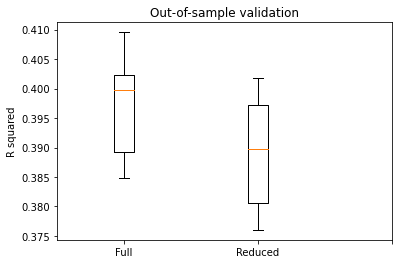

In [17]:
fig, ax = plt.subplots()
ax.boxplot([scores_full, scores_reduced])
plt.xticks([1, 2, 3], ['Full', 'Reduced'])
plt.ylabel('R squared')
plt.title('Out-of-sample validation')
# FDR was probably too conservative? 
# You can experiment and try to see whether performance improves if you relax FDR. 
# Or we actually did not have an overfitting problem here (as N is still large relative to the number of covariates)
# and we capture the most informative text data with the LDA components

#### Lasso regression 

In [18]:
from sklearn.linear_model import Lasso
y = data['favorite_count']

# it is recommended to drop the reference category
dummies = [pd.get_dummies(data[i], prefix=i, drop_first = False) for i in ['year', 'dayofyear', 'dayofweek', 'hour']]

X = data.iloc[:, 9:].join(dummies)
X = pd.DataFrame(np.ascontiguousarray(X.values), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1)
pipe = Pipeline([('scaler', StandardScaler()),
                 ('lasso', 
                  Lasso(alpha=0.05, fit_intercept=True, normalize=False, copy_X=False, max_iter=10000))])
# note alpha == lambda in the lecture notes; we just take some value - it is not the optimal! 
# again if you simply follow the defaults, it is not necessary to specify the options
pipe.fit(X_train, y_train)
print('In-sample Rsq: % .4f'
     % pipe.score(X_train, y_train))
print('Out-of-sample Rsq: % .4f'
     % pipe.score(X_test, y_test))
#print(regr.coef_)

In-sample Rsq:  0.3772
Out-of-sample Rsq:  0.3643


#### Lasso regularisation path

In [19]:
# lasso path
from sklearn.linear_model import lasso_path, enet_path

y = data['favorite_count']
X = data.iloc[:, 9:].join(dummies)
X = pd.DataFrame(np.ascontiguousarray(X.values), columns=X.columns)
X = StandardScaler().fit_transform(X) 

# Compute paths
eps = 0.0015 #the smaller it is the longer is the path; 0 = OLS. If it is very small: the model might not find a solution
print("Computing regularization path using the lasso...")
alphas_lasso, coefs_lasso, _ = lasso_path(X, y, eps=eps, max_iter=10000, fit_intercept=True)
print("Ready")

Computing regularization path using the lasso...
Ready


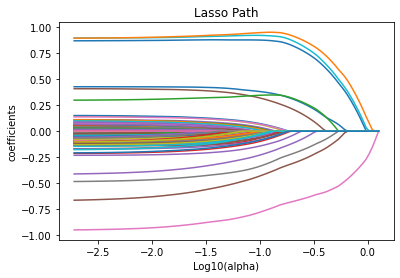

In [20]:
# Display results
plt.figure()
log_alphas_lasso = np.log10(alphas_lasso)
for coef_l in coefs_lasso:
    l1 = plt.plot(log_alphas_lasso, coef_l)

plt.xlabel('Log10(alpha)')
plt.ylabel('coefficients')
plt.title('Lasso Path')
plt.axis('tight')
plt.show()

# what if we do not standardise covariates, how will the lasso path look like? 
# try to comment out the StandardScaler() and see how the path looks

# https://scikit-learn.org/stable/auto_examples/linear_model/plot_lasso_coordinate_descent_path.html#sphx-glr-auto-examples-linear-model-plot-lasso-coordinate-descent-path-py

#### Selecting optimal $\lambda$ with cross-validation and information criteria

In [24]:
# Use K-fold out-of-sample validation to select the 'best' $\lambda$. Plot average out-of-sample error as a function of $\lambda$. 
from sklearn.linear_model import LassoCV
import time

y = data['favorite_count']
X = data.iloc[:, 9:].join(dummies)
X = pd.DataFrame(np.ascontiguousarray(X.values), columns=X.columns)

pipe = Pipeline([('scaler', StandardScaler()),
                 ('lassocv', LassoCV(cv=5, max_iter=10000, alphas=np.logspace(-2.2, -0.5, 100), fit_intercept=True))])

print("Computing Lasso CV...")
t1 = time.time()
pipe.fit(X, y)
t_cv = time.time() - t1
print("Ready")

Computing Lasso CV...
Ready


In [25]:
l = pipe.named_steps.lassocv #the output of lassocv step is stored here
print("Optimal alpha = % .4f " % l.alpha_)
print("Training time = % .4fs " % t_cv)

Optimal alpha =  0.0105 
Training time =  16.0525s 


(-2.285, -0.415, 3.3847238863530382, 38.844523736842746)

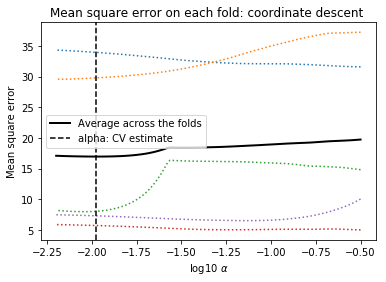

In [26]:
# Display results
log_alphas_lasso = np.log10(l.alphas_)

plt.figure()
plt.plot(log_alphas_lasso , l.mse_path_, ':')
plt.plot(log_alphas_lasso , l.mse_path_.mean(axis=-1), 'k',
         label='Average across the folds', linewidth=2)
plt.axvline(np.log10(l.alpha_) , linestyle='--', color='k',
            label='alpha: CV estimate')

plt.legend()

plt.xlabel(r'log10 $\alpha$')
plt.ylabel('Mean square error')
plt.title('Mean square error on each fold: coordinate descent ')
plt.axis('tight')

In [ ]:
#lasso.coef_

In [27]:
# We can compare this result with alpha selected with BIC/AIC criterion
from sklearn.linear_model import  LassoLarsIC

model_bic = LassoLarsIC(criterion='bic')
t1 = time.time()
model_bic.fit(X, y)
t_bic = time.time() - t1
alpha_bic_ = model_bic.alpha_

model_aic = LassoLarsIC(criterion='aic')
model_aic.fit(X, y)
alpha_aic_ = model_aic.alpha_
print("Ready")
print("Optimal alpha aic = % .6f " % alpha_aic_)
print("Optimal alpha bic = % .6f " % alpha_bic_)
print("Training time = % .4fs " % t_bic)

Ready
Optimal alpha aic =  0.000004 
Optimal alpha bic =  0.000300 
Training time =  2.8078s 


Text(0.5, 1.0, 'Information-criterion for model selection ')

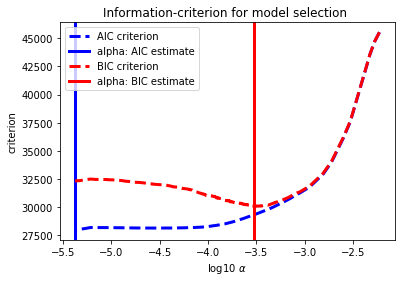

In [28]:
def plot_ic_criterion(model, name, color):
    criterion_ = model.criterion_
    plt.plot(np.log10(model.alphas_), criterion_, '--', color=color,
                 linewidth=3, label='%s criterion' % name)
    plt.axvline(np.log10(model.alpha_), color=color, linewidth=3,
                label='alpha: %s estimate' % name)
    plt.xlabel(r'log10 $\alpha$')
    plt.ylabel('criterion')

plt.figure()
plot_ic_criterion(model_aic, 'AIC', 'b')
plot_ic_criterion(model_bic, 'BIC', 'r')
plt.legend()
plt.title('Information-criterion for model selection ')

In [29]:
# Compare performance of lasso model with the baseline model
y = data['favorite_count']
X = data.iloc[:, 9:].join(dummies)
X = pd.DataFrame(np.ascontiguousarray(X.values), columns=X.columns)

kf = KFold(n_splits=5, shuffle=True, random_state=1)

pipe = Pipeline([('scaler', StandardScaler()),
                 ('lasso', 
                  Lasso(alpha=l.alpha_, fit_intercept=True, normalize=False, copy_X=False, max_iter=10000))])
scores_lasso = cross_val_score(pipe, X, y, cv=kf)
print(scores_lasso)
print("Accuracy: %0.5f (+/- %0.5f)" % (scores_lasso.mean(), scores_lasso.std() * 2))

# if you decide to check for AIC, will take time, as lambda is very small, the result will be very close to a simple OLS

[0.37620098 0.39200721 0.38662761 0.38450228 0.40023238]
Accuracy: 0.38791 (+/- 0.01597)


Text(0.5, 1.0, 'Out-of-sample validation')

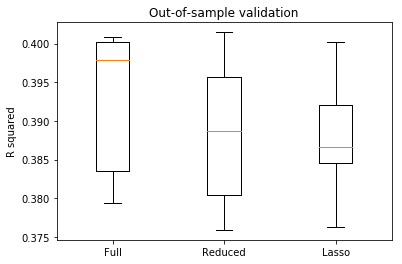

In [30]:
fig, ax = plt.subplots()
ax.boxplot([scores_full, scores_reduced, scores_lasso])
plt.xticks([1, 2, 3], ['OLS', 'FDR', 'Lasso'])
plt.ylabel('R squared')
plt.title('Out-of-sample validation')

#### Comparing models' performance on a small sample

In [31]:
# As an exercise, we can replicate the estimations but for a much larger sample
# Let's randomly select only 10% from our sample
data_sm = data.sample(frac=0.1, replace=False, weights=None, random_state=1, axis=0)
data_sm.describe()

,id_str,retweet_count,favorite_count,year,month,dayofyear,dayofweek,hour,length,length2,...,lda_topic_90,lda_topic_91,lda_topic_92,lda_topic_93,lda_topic_94,lda_topic_95,lda_topic_96,lda_topic_97,lda_topic_98,lda_topic_99
count,4.554000e+03,4554.000000,4554.000000,4554.000000,4554.000000,4554.000000,4554.000000,4554.000000,4554.000000,4554.000000,...,4554.000000,4554.000000,4554.000000,4554.000000,4554.000000,4554.000000,4554.000000,4554.000000,4554.000000,4554.000000
mean,7.286968e+17,7889.556873,5.840328,2015.851998,6.430391,180.160957,2.689504,12.999561,4.753860,9.486688,...,0.007818,0.009239,0.012720,0.006961,0.007570,0.008512,0.014576,0.010116,0.008802,0.010837
std,3.536381e+17,12062.940382,4.186149,2.693520,3.519655,107.127782,1.929060,5.599881,0.589705,1.194832,...,0.042218,0.050596,0.060653,0.035102,0.038270,0.042506,0.065187,0.054178,0.045500,0.055658
min,1.864367e+09,0.000000,0.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,1.791759,3.258097,...,0.000714,0.000714,0.000714,0.000714,0.000828,0.000714,0.000828,0.000714,0.000714,0.000714
25%,4.100225e+17,39.000000,2.656306,2013.000000,3.000000,84.000000,1.000000,8.000000,4.532599,9.043695,...,0.002296,0.002296,0.002302,0.002296,0.002296,0.002296,0.002302,0.002294,0.002296,0.002301
50%,6.633298e+17,1484.000000,4.927254,2015.000000,7.000000,183.000000,3.000000,13.000000,4.875197,9.735128,...,0.002545,0.002545,0.002554,0.002546,0.002545,0.002548,0.002557,0.002543,0.002546,0.002550
75%,1.108288e+18,13256.250000,10.591905,2019.000000,10.000000,279.000000,4.000000,17.000000,4.941642,9.869000,...,0.002952,0.002959,0.002989,0.002957,0.002957,0.002970,0.003012,0.002956,0.002962,0.002969
max,1.261787e+18,220796.000000,13.546760,2020.000000,12.000000,365.000000,6.000000,23.000000,8.590815,17.181259,...,0.780118,0.793503,0.781814,0.664258,0.688657,0.739698,0.754312,0.760431,0.774097,0.759072


In [32]:
dummies = [pd.get_dummies(data_sm[i], prefix=i, drop_first = False) for i in ['year', 'dayofyear', 'dayofweek', 'hour']]

y = data_sm['favorite_count']
X = data_sm.iloc[:, 9:].join(dummies)
X = pd.DataFrame(np.ascontiguousarray(X.values), columns=X.columns)

In [33]:
# K-fold cross-validation
# Linear model
kf = KFold(n_splits=5, shuffle=True, random_state=1)

pipe = Pipeline([('scaler', StandardScaler()),
                 ('regr', LinearRegression(fit_intercept = True, normalize=False, copy_X=False, n_jobs=-1))])
scores_full = cross_val_score(pipe, X, y, cv=kf)
print(scores_full)
print("Accuracy: %0.5f (+/- %0.5f)" % (scores_full.mean(), scores_full.std() * 2))

[0.27087178 0.30021178 0.31434197 0.27710995 0.28842012]
Accuracy: 0.29019 (+/- 0.03138)


In [34]:
# FDR selection
pipe = Pipeline([('scaler', StandardScaler()),
                 ('fdr', SelectFdr(f_regression, alpha=0.05)),
                 ('regr', LinearRegression(fit_intercept = True, normalize=False, copy_X=False, n_jobs=-1))])
scores_reduced = cross_val_score(pipe, X, y, cv=kf)
print(scores_reduced)
print("Accuracy: %0.5f (+/- %0.5f)" % (scores_reduced.mean(), scores_reduced.std() * 2))

[0.32883862 0.34887843 0.35428805 0.32533431 0.33910206]
Accuracy: 0.33929 (+/- 0.02229)


In [35]:
# optimal lasso
pipe = Pipeline([('scaler', StandardScaler()),
                 ('lassocv', LassoCV(cv=5, max_iter=10000, alphas=np.logspace(-2.5, -0.5, 100), fit_intercept=True))])

print("Computing Lasso CV...")
t1 = time.time()
pipe.fit(X, y)
t_cv = time.time() - t1
print("Ready")
l = pipe.named_steps.lassocv #the output of lassocv step is stored here
print("Optimal alpha = % .4f " % l.alpha_)
print("Training time = % .4fs " % t_cv)

Computing Lasso CV...
Ready
Optimal alpha =  0.0566 
Training time =  2.1955s 


In [36]:
pipe = Pipeline([('scaler', StandardScaler()),
                 ('lasso', 
                  Lasso(alpha=l.alpha_, fit_intercept=True, normalize=False, copy_X=False, max_iter=10000))])
scores_lasso = cross_val_score(pipe, X, y, cv=kf)
print(scores_lasso)
print("Accuracy: %0.5f (+/- %0.5f)" % (scores_lasso.mean(), scores_lasso.std() * 2))

[0.32527731 0.34246206 0.35390632 0.31654732 0.34945735]
Accuracy: 0.33753 (+/- 0.02864)


Text(0.5, 1.0, 'Out-of-sample validation, smaller sample')

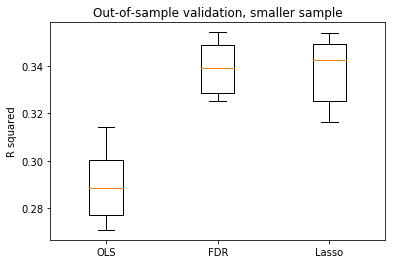

In [37]:
fig, ax = plt.subplots()
ax.boxplot([scores_full, scores_reduced, scores_lasso])
plt.xticks([1, 2, 3], ['OLS', 'FDR', 'Lasso'])
plt.ylabel('R squared')
plt.title('Out-of-sample validation, smaller sample')

## Problem set: Control selection exercise 

In Stata

## Resources 
* Athey and Imbens (2019) Machine Learning Methods Economists Should Know About
* Matt Taddy (2019) Business Data Science: Combining Machine Learning and Economics to Optimize, Automate, and Accelerate Business Decisions. McGraw-Hill Education
* [Video lectures on statistical learning](https://www.r-bloggers.com/in-depth-introduction-to-machine-learning-in-15-hours-of-expert-videos/)
* [Stata packages for Lasso](https://www.stata.com/meeting/uk18/slides/uk18_Ahrens.pdf)
